# Capítulo 14: Regularização e seleção de modelos

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

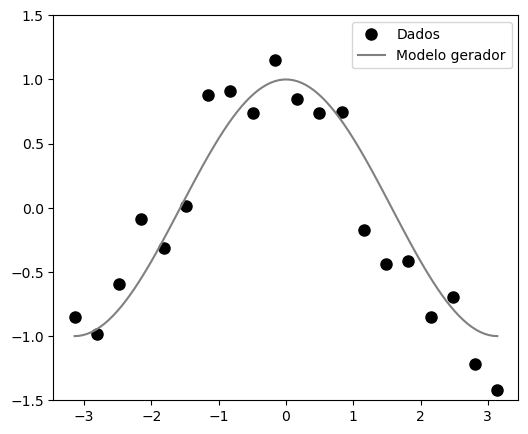

Parameters: [-0.09032347]


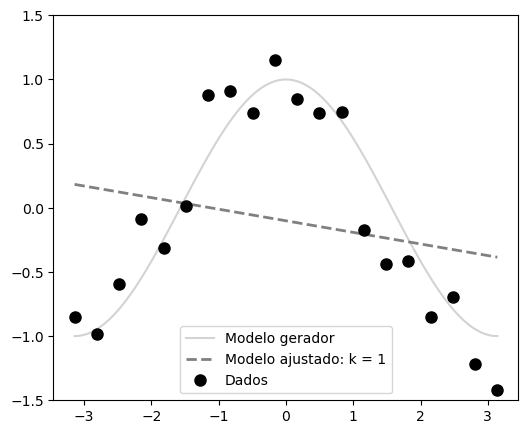

RSS: 11.753427267856893
Parameters: [-0.09032347 -0.21738074]


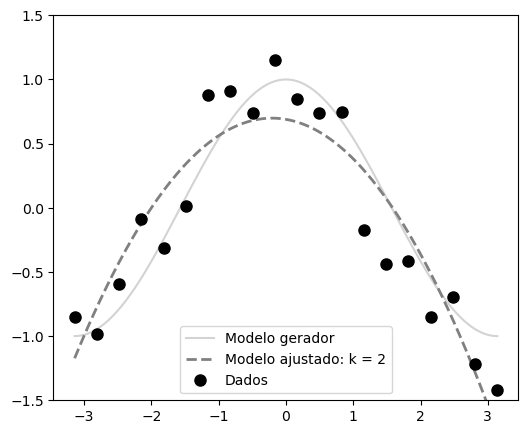

RSS: 1.8320312629407354
Parameters: [-0.17057116 -0.21738074  0.01230182]


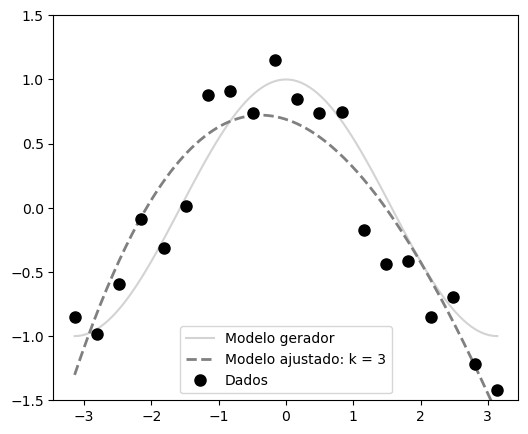

RSS: 1.7446912024388688
Parameters: [-1.12566117e+00 -2.62907235e+00  8.31071286e+00  6.42414392e+00
 -1.94803684e+01 -4.16731864e+00  2.00797207e+01 -2.63413541e+00
 -1.11801329e+01  4.38150549e+00  3.67116362e+00 -2.19995300e+00
 -7.29442455e-01  5.57328669e-01  8.57744917e-02 -7.66211924e-02
 -5.46513115e-03  5.42930092e-03  1.44710679e-04 -1.54918081e-04]


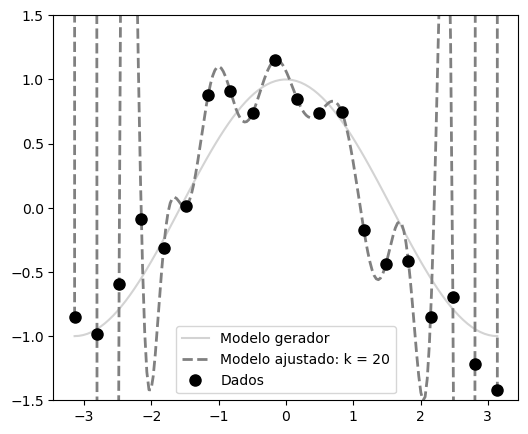

RSS: 2.0144304238425268e-09


In [1]:
# Pág. 407
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
np.random.seed(42)

#função para gerar os dados
def gera_dados(x, sigma):
    y = np.cos(x) + np.random.normal(0, sigma, len(x))
    return y

# gera os dados de treinamento
n_train = 20
sigma = 0.3
min_X = -np.pi; max_X = np.pi
X_train= np.linspace(min_X,max_X,n_train)
y_train = gera_dados(X_train, sigma)
X_train = X_train.reshape(len(X_train), 1)

# mostra o conjunto de treinamento
plt.figure(figsize=(6,5))
plt.plot(X_train, y_train, color='black', 
         marker = 'o', markersize=8, 
         linestyle='none', label="Dados")

# mostra o modelo gerador dos dados
Xm = np.linspace(min_X,max_X,100)
yt = gera_dados(Xm, 0)
plt.plot(Xm,yt, color = 'gray', 
         linestyle='-',  label="Modelo gerador")
plt.legend(fontsize = 10)
plt.ylim([-1.5, 1.5])
plt.show(True)

# graus do polinômio
degrees = [1,2,3,20]
for dg in degrees:
    # Define a matriz de atributos
    poly3 = PolynomialFeatures(degree=dg, include_bias=False)
    X = poly3.fit_transform(X_train) 
    # ajusta o modelo
    model = LinearRegression()
    model.fit(X,y_train)
    print("Parameters:", model.coef_)
    # mostra a curva obtida a partir da predição
    xp = np.linspace(min_X,max_X,200)
    Xplot = xp.reshape(len(xp), 1)
    Xplot=poly3.fit_transform(Xplot)
    # faz a predição
    y_pred = model.predict(Xplot)
    # mostra os resultados
    plt.figure(figsize=(6,5))
    plt.plot(Xm,yt, color = 'lightgray', 
             linestyle='-',  label="Modelo gerador")

    plt.plot(xp, y_pred, color = 'gray',linestyle='--', 
             linewidth = 2,
             label = 'Modelo ajustado: k = '+str(dg))
    plt.plot(X_train, y_train, color='black', 
             marker = 'o', markersize=8, 
             linestyle='none', label="Dados")
    plt.ylim([-1.5, 1.5])
    plt.legend(fontsize=10)
    y_pred_train = model.predict(X)
    plt.show(True)
    rss = np.sum((y_train - y_pred_train)**2)
    print('RSS:', rss)

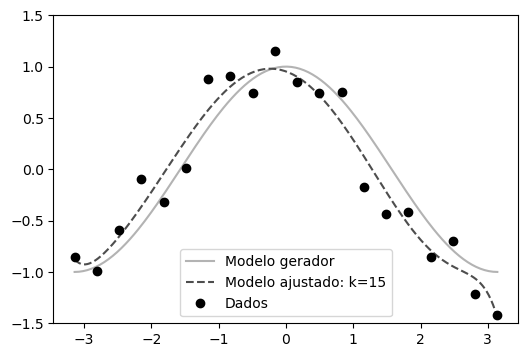

Coeficientes estimados:
[-0.44545119 -1.62157528  0.39857719  1.21574997  0.         -0.
 -0.         -0.29244033 -0.         -0.         -0.         -0.
 -0.01919819  0.         -0.13013972] -0.10138956843254866


In [2]:
# Pág. 416
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso

np.random.seed(42)

# função geradora de dados
def gera_dados(x, sigma):
    y = np.cos(x) + np.random.normal(0, sigma, len(x))
    return y

# conjunto de treinamento
n_train = 20 # número de observações
sigma = 0.3  # nível de ruído no treinamento
min_X, max_X = -np.pi, np.pi 
x_vals = np.linspace(min_X, max_X, n_train)
X_train = x_vals.reshape(-1, 1)               
# ravel() para passar vetor 1D à função geradora
y_train = gera_dados(X_train.ravel(), sigma)

k = 15  # grau do polinômio (complexidade do modelo)

# pipeline:
model = make_pipeline(
    # geração de atributos polinomiais
    PolynomialFeatures(degree=k, include_bias=False),
    # padronização dos dados
    StandardScaler(),
    # regressão Lasso (regularização L1)
    Lasso(alpha=1e-3, max_iter=20000, random_state=42)
)

# ajuste do modelo ao conjunto de treinamento
model.fit(X_train, y_train)

# predição em uma grade densa para desenhar as curvas
xp = np.linspace(min_X, max_X, 200).reshape(-1, 1)  
y_pred = model.predict(xp)                          

# modelo gerador sem ruído, para comparação visual
Xm = np.linspace(min_X, max_X, 200)
yt = gera_dados(Xm, 0) 

# mostra os resultados
plt.figure(figsize=(6, 4))
plt.plot(Xm, yt, linestyle='-', 
         label="Modelo gerador", color='0.7')
plt.plot(xp.ravel(), y_pred, linestyle='--', 
         label=f"Modelo ajustado: k={k}", color='0.3')
plt.plot(X_train.ravel(), y_train, 'o', label="Dados", color='0')
plt.ylim([-1.5, 1.5])
plt.legend(fontsize=10)
plt.show()

print("Coeficientes estimados:")
lasso = model.named_steps['lasso']
print(lasso.coef_, lasso.intercept_)

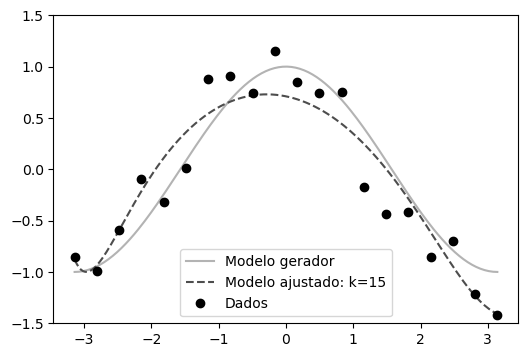

Coeficientes:
[-0.25610699 -0.74719264  0.06290238 -0.1274162   0.08749298  0.03680925
  0.0527687   0.06404657  0.01362799  0.05822715 -0.0197625   0.04821446
 -0.04612659  0.04063183 -0.06621463] -0.10138956843254865


In [3]:
# Pág. 418
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge

np.random.seed(42)

# função geradora de dados
def gera_dados(x, sigma):
    y = np.cos(x) + np.random.normal(0, sigma, len(x))
    return y

# gera os dados de treinamento
n_train = 20 # número de observações
sigma = 0.3  # nível de ruído no treinamento
min_X, max_X = -np.pi, np.pi 
X_train = np.linspace(min_X, max_X, n_train)
X_train = X_train[:, None]
# ravel() para passar vetor 1D à função geradora
y_train = gera_dados(X_train.ravel(), sigma)

k = 15  # grau do polinômio (complexidade do modelo)
alpha = 1.0
# pipeline:
model = make_pipeline(
    PolynomialFeatures(degree=k, include_bias=False),
    StandardScaler(),    
    Ridge(alpha=alpha, fit_intercept=True)
)

# ajuste do modelo ao conjunto de treinamento
model.fit(X_train, y_train)

# predição em uma grade densa para desenhar as curvas
xp = np.linspace(min_X, max_X, 200).reshape(-1, 1)  
y_pred = model.predict(xp)                          

# modelo gerador sem ruído, para comparação visual
Xm = np.linspace(min_X, max_X, 200)
yt = gera_dados(Xm, 0) 

# mostra os resultados
plt.figure(figsize=(6, 4))
plt.plot(Xm, yt, linestyle='-', 
         label="Modelo gerador", color='0.7')
plt.plot(xp.ravel(), y_pred, linestyle='--', 
         label=f"Modelo ajustado: k={k}", color='0.3')
plt.plot(X_train.ravel(), y_train, 'o', 
         label="Dados", color='0')
plt.ylim([-1.5, 1.5])
plt.legend(fontsize=10)
plt.show()

print("Coeficientes:")
ridge = model.named_steps['ridge']
print(ridge.coef_, ridge.intercept_)

Variáveis selecionadas: ['X1', 'X2']


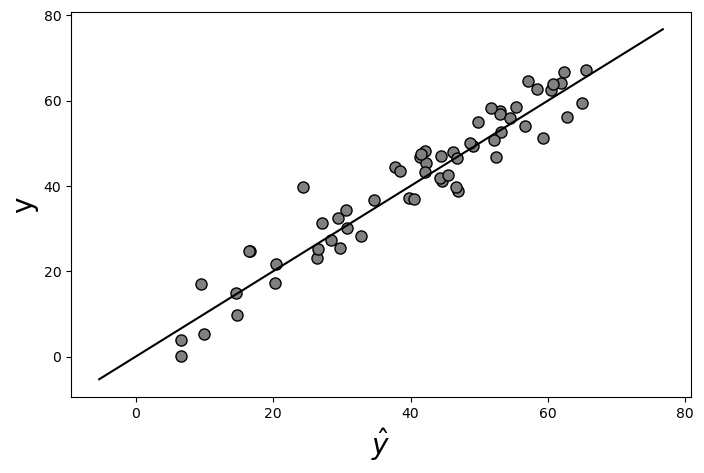

In [4]:
# Pág. 421
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
np.random.seed(42)

n = 200 # número de observações
# gera os dados
x1 = np.random.uniform(0,5, (n, 1));
x2 = np.random.uniform(0,20, (n, 1));
x3 = np.random.uniform(0,30, (n, 1));
x4 = 3*x2 + 1
e = np.random.normal(0,5, (n, 1));
y = 4 + 2*x1 + 3*x2 + e

data = pd.DataFrame(data=np.column_stack(((x1, x2, x3, x4, y))), columns=['X1', 'X2', 'X3', 'X4', 'y'])
data.head()

# converte para o numpy
df = data.to_numpy()
nrow,ncol = df.shape
y = df[:,-1]
X = df[:,0:ncol-1]

# seleciona o treinamento e teste
p = 0.3 # fracao de elementos no conjunto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

# define o modelo
model = LinearRegression()
# realiza a seleção de atributos
kf = KFold(n_splits=5, shuffle=True, random_state=42)
sfs = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=2,
    direction='forward',
    scoring='r2',
    cv=kf,
    n_jobs=-1
)
sfs.fit(X_train, y_train)
# variáveis selecionadas
var_sel = sfs.get_support()
print('Variáveis selecionadas:', 
      list(data.columns[np.where(var_sel)[0]]))
X_train_sel = X_train[:,var_sel]
X_test_sel = X_test[:,var_sel]

# ajusta o modelo
model = LinearRegression()
model.fit(X_train_sel, y_train)
# faz a predição
y_pred = model.predict(X_test_sel)

# mostra os resultados
plt.figure(figsize=(8,5))
plt.plot(y_pred, y_test, color='gray', marker = 'o', 
         markersize=8, linestyle='none',
        markeredgecolor='black')
# mostra a linha x = y
xx = [min(y),max(y)]
plt.plot(xx,xx, 
         color = 'black', linestyle='-')
plt.ylabel("y", fontsize=20)
plt.xlabel(r"$\hat{y}$", fontsize=20)
plt.show(True)

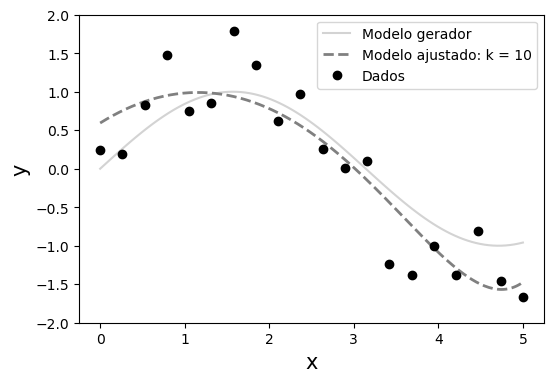

[ 1.04105606 -2.3311718  -0.         -0.          0.          0.
  0.          0.49561218  0.          0.        ]


In [5]:
# Pág. 424
from matplotlib import pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso

np.random.seed(42)

# função para gerar os dados
def gera_dados(x, sigma):
    y = np.sin(x) + np.random.normal(0, sigma, len(x))
    return y

# gera os dados de treinamento
n_train = 20
sigma = 0.5
min_X = 0; max_X = 5
X_train = np.linspace(min_X, max_X, n_train)   
y_train = gera_dados(X_train, sigma)           
X_train = X_train.reshape(-1, 1)               

k = 10  # grau do polinômio
alpha = 0.01
# Pipeline: expansão polinomial -> padronização -> Lasso
model = make_pipeline(
    PolynomialFeatures(degree=k, include_bias=False),
    StandardScaler(), # padroniza os dados
    Lasso(alpha=alpha, max_iter=50000, random_state=42)
)

# ajusta o modelo usando Lasso com padronização
model.fit(X_train, y_train)

# calcula a curva de predição
xp = np.linspace(min_X, max_X, 200).reshape(-1, 1)
y_pred = model.predict(xp)

# mostra os resultados
# o modelo gerador dos dados (sem ruído)
Xm = np.linspace(min_X, max_X, 100)
yt = gera_dados(Xm, 0)

plt.figure(figsize=(6,4))
plt.plot(Xm, yt, color='lightgray', 
         linestyle='-', label="Modelo gerador")
plt.plot(xp.ravel(), y_pred, 
         color='gray', linestyle='--',
         linewidth=2, label=f"Modelo ajustado: k = {k}")
plt.plot(X_train.ravel(), y_train, 
         color='black', marker='o',
         markersize=6, linestyle='none', 
         label="Dados")
plt.ylim([-2, 2])
plt.legend(fontsize=10)
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
plt.show()

# imprime os coeficientes do Lasso 
lasso = model.named_steps['lasso']
print(lasso.coef_)

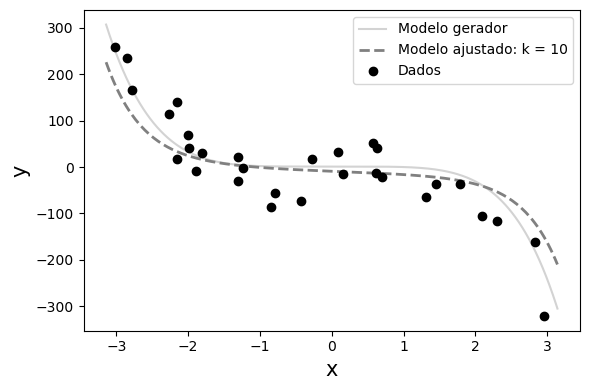

Coeficientes:
[-11.02933417   1.30753177 -13.41495955   1.12795996 -13.12788997
   0.77284636 -12.60118909   0.50958944 -12.18146625   0.33494173]


In [6]:
# Pág. 426
from matplotlib import pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# função para gerar os dados (vetorizada)
def gera_dados(x, sigma):
    x = np.asarray(x).ravel()
    E = np.random.normal(0, sigma, size=x.shape[0])
    return np.exp(-0.01 * x) - x**5 + E

# gera os dados de treinamento
n_train = 30
sigma = 50
min_X, max_X = -np.pi, np.pi
X_train = np.random.uniform(min_X, max_X, size=(n_train, 1))
y_train = gera_dados(X_train, sigma)   # y 1D

k = 10  # grau do polinômio

# Pipeline: expansão polinomial -> padronização -> Ridge
model = make_pipeline(
    PolynomialFeatures(degree=k, include_bias=False),
    StandardScaler(), # padroniza os dados
    Ridge(alpha=100, fit_intercept=True)
)

# ajusta o modelo usando Ridge
model.fit(X_train, y_train)

# calcula a curva de predição
xp = np.linspace(min_X, max_X, 200).reshape(-1, 1)
y_pred = model.predict(xp)

# curva do modelo gerador (sem ruído), para comparação
Xm = np.linspace(min_X, max_X, 400)
ym = gera_dados(Xm, 0)

# visualização
plt.figure(figsize=(6, 4))
plt.plot(Xm, ym, color='lightgray', 
         linestyle='-', label="Modelo gerador")
plt.plot(xp.ravel(), y_pred, color='gray', 
         linestyle='--',
         linewidth=2, 
         label=f"Modelo ajustado: k = {k}")
plt.plot(X_train.ravel(), y_train, 
         color='black', marker='o',
         markersize=6, linestyle='none', 
         label="Dados")
plt.legend(fontsize=10)
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
plt.tight_layout()
plt.show()

ridge = model.named_steps['ridge']
print("Coeficientes:")
print(ridge.coef_)

Variáveis selecionadas: ['freq', 'comp', 'suc']
R2 (teste): 0.4046
RMSE (teste): 28.1111


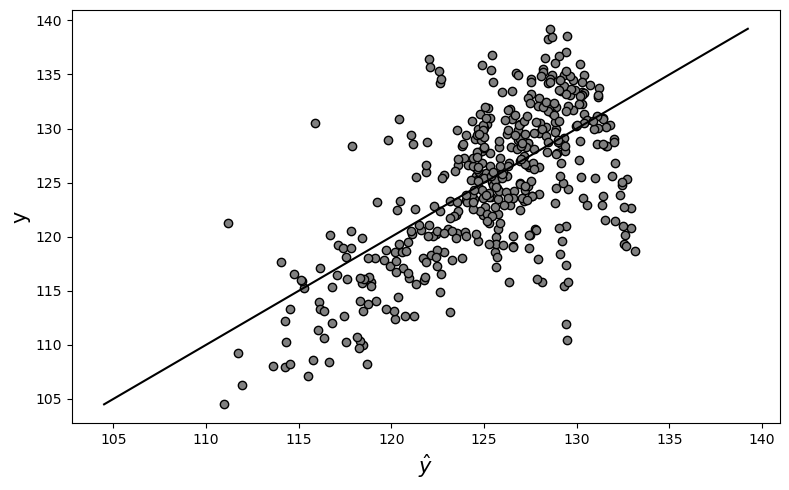

In [7]:
# Pág. 428
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(42)

# leitura dos dados
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat'
data = pd.read_csv(url, sep=r'\s+', 
                   header=None, engine='python')
data.columns = ['freq', 'angle', 
                'comp', 'vel', 'suc', 'pres'] 

# separa X e y
X = data[['freq', 'angle', 'comp', 
          'vel', 'suc']].to_numpy()
y = data['pres'].to_numpy()

# treino/teste
p = 0.30  # fração no conjunto de teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=p, random_state=42
)

# pipeline: padronização + regressão linear
pipe = make_pipeline(StandardScaler(), 
                     LinearRegression())

# seleção sequencial de 3 atributos
cv = KFold(n_splits=5, shuffle=True, random_state=42)
sfs = SequentialFeatureSelector(
    estimator=pipe,
    n_features_to_select=3,
    direction='forward',
    scoring='r2',
    cv=cv,
    n_jobs=-1
)
sfs.fit(X_train, y_train)

# variáveis selecionadas
var_sel = sfs.get_support()
sel_names = list(data.columns[:-1][np.where(var_sel)[0]])
print('Variáveis selecionadas:', sel_names)

# restringe os conjuntos às colunas selecionadas
X_train_sel = X_train[:, var_sel]
X_test_sel  = X_test[:, var_sel]

# novo pipeline apenas com as variáveis selecionadas
final_model = make_pipeline(StandardScaler(), 
                            LinearRegression())
final_model.fit(X_train_sel, y_train)

# predições no teste
y_pred = final_model.predict(X_test_sel)

# métricas
r2  = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
print(f'R2 (teste): {r2:.4f}')
print(f'RMSE (teste): {rmse:.4f}')

# mostra os resultados
plt.figure(figsize=(8,5))
plt.plot(y_pred, y_test, 'o', color='gray', 
         markeredgecolor='black', markersize=6, 
         linestyle='none')
# linha diagonal \hat{y} = y
mn = min(y_pred.min(), y_test.min())
mx = max(y_pred.max(), y_test.max())
plt.plot([mn, mx], [mn, mx], 'k-')
plt.xlabel(r'$\hat{y}$', fontsize=15)
plt.ylabel('y', fontsize=15)
plt.tight_layout()
plt.show()